# YOLOV11 Ultralytics Implementation
**res:640x640,RGB**

## INIT

### CHECK COLAB

In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!nvidia-smi

Fri May  8 10:20:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   33C    P8              8W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

**NOTE:** To make it easier for us to manage datasets, images and models we create a `HOME` constant.

In [2]:
import os
HOME = os.getcwd()
print(HOME)

/content


### INSTALL YOLOV11 ULTRALYTICS

In [ ]:
%pip install "ultralytics<=8.3.40" supervision
# prevent ultralytics from tracking your activity
!yolo settings sync=False
import ultralytics
ultralytics.checks()

Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 43.1/112.6 GB disk)


### CUSTOM TRAINING

**NOTE:** When training YOLOv11, make sure your data is located in `datasets`. If you'd like to change the default location of the data you want to use for fine-tuning, you can do so through Ultralytics' `settings.json`.

In [ ]:
!mkdir -p {HOME}/datasets
%cd {HOME}/datasets

CUSTOM_DATASET_ZIP_PATH = '/content/drive/MyDrive/yolo_zips/Holes.v1i.yolov11.zip' 
CUSTOM_DATASET_UNZIPPED_DIR = f"{HOME}/datasets/custom_yolov11_data"

# copy the zipped dataset from drive to colab 
!cp "{CUSTOM_DATASET_ZIP_PATH}" {HOME}/datasets/

zip_filename = os.path.basename(CUSTOM_DATASET_ZIP_PATH)

!unzip -q {HOME}/datasets/{zip_filename} -d {CUSTOM_DATASET_UNZIPPED_DIR}

print(f"unzipped to: {CUSTOM_DATASET_UNZIPPED_DIR}")

!ls {HOME}/datasets
%cd {HOME}

/content/datasets
replace /content/datasets/custom_yolov11_data/data.yaml? [y]es, [n]o, [A]ll, [N]one, [r]ename: Custom dataset unzipped to: /content/datasets/custom_yolov11_data
custom_yolov11_data  Holes.v1i.yolov11.zip
/content


In [ ]:

!ls -F {CUSTOM_DATASET_UNZIPPED_DIR}
DATA_FILE = f"{CUSTOM_DATASET_UNZIPPED_DIR}/data.yaml"
!cat "$DATA_FILE"


data.yaml  test/  train/  valid/
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 1
names: ['hole']

roboflow:
  workspace: fayazs-workspace
  project: holes-u3z03-jthiw
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/fayazs-workspace/holes-u3z03-jthiw/dataset/1

In [ ]:
!yolo task=detect mode=train model=yolo11s.pt data={CUSTOM_DATASET_UNZIPPED_DIR}/data.yaml epochs=25 imgsz=640 plots=True

New https://pypi.org/project/ultralytics/8.4.48 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolo11s.pt, data=/content/datasets/custom_yolov11_data/data.yaml, epochs=25, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train2, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, s

### INFO

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/confusion_matrix.png', width=600)

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/results.png', width=600)

In [ ]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'{HOME}/runs/detect/train/val_batch0_pred.jpg', width=600)

## VALIDATE

In [13]:
# Validate fine-tuned model with your custom dataset
!yolo task=detect mode=val model={HOME}/runs/detect/train/weights/best.pt data={CUSTOM_DATASET_UNZIPPED_DIR}/data.yaml

Traceback (most recent call last):
  File "/usr/local/bin/yolo", line 8, in <module>
    sys.exit(entrypoint())
             ^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/cfg/__init__.py", line 943, in entrypoint
    model = YOLO(model, task=task)
            ^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/models/yolo/model.py", line 23, in __init__
    super().__init__(model=model, task=task, verbose=verbose)
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/engine/model.py", line 145, in __init__
    self._load(model, task=task)
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/engine/model.py", line 288, in _load
    self.model, self.ckpt = attempt_load_one_weight(weights)
                            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ultralytics/nn/tasks.py", line 910, in attempt_load_one_weight
    ckpt, weight = torch_safe_load(weight)  # load ckpt
     

## INFERENCE

In [ ]:
!ls {HOME}/runs/detect/predict
import os
import random
from IPython.display import Image as IPyImage, display

image_name= "image_52_png.rf.Wl679GvVIGKxMcekSVNf.jpg"
predicted_image_path=os.path.join(f"{HOME}/datasets/runs/detect/predict", image_name)
if os.path.exists(predicted_image_path):
    display(IPyImage(filename=predicted_image_path, width=600))
else:
    print(f"Predicted image not found at {predicted_image_path}")


image_28_png.rf.abc79c22e8b90e6b596f961d56007265.jpg
Predicted image not found at /content/datasets/runs/detect/predict/image_52_png.rf.Wl679GvVIGKxMcekSVNf.jpg


To check how your trained model performs on a single image from your training files, we can pick a random image from the `train/images` directory within your custom dataset and run inference on it.

/content
Running inference on a random training image: /content/datasets/custom_yolov11_data/train/images/image_86_png.rf.83adb1aa63bcf35a3e6c39ebffe84565.jpg
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 238 layers, 9,413,187 parameters, 0 gradients, 21.3 GFLOPs

image 1/1 /content/datasets/custom_yolov11_data/train/images/image_86_png.rf.83adb1aa63bcf35a3e6c39ebffe84565.jpg: 640x640 43 holes, 15.5ms
Speed: 3.5ms preprocess, 15.5ms inference, 74.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to runs/detect/predict4
💡 Learn more at https://docs.ultralytics.com/modes/predict


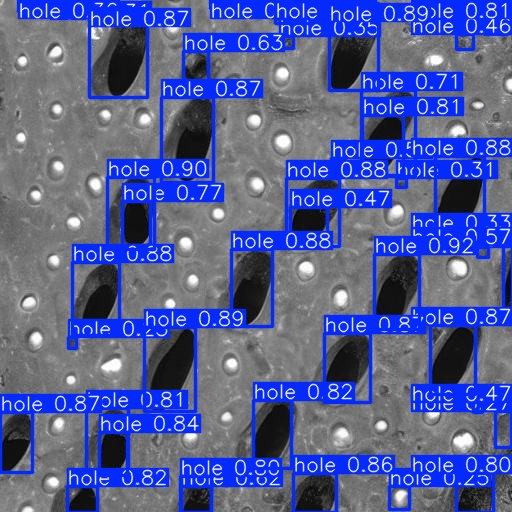

In [ ]:
import os
import random
from IPython.display import Image as IPyImage, display

%cd {HOME}

# Path to your training images
train_images_dir = f"{CUSTOM_DATASET_UNZIPPED_DIR}/train/images"

# Get a list of all image files in the training directory
all_train_images = [f for f in os.listdir(train_images_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tiff', '.bmp', '.gif'))]

# Select a random image from the training set
if all_train_images:
    random_train_image = random.choice(all_train_images)
    single_image_path = os.path.join(train_images_dir, random_train_image)
    print(f"Running inference on a random training image: {single_image_path}")

    # Run inference on the selected training image
    !yolo task=detect mode=predict model={HOME}/runs/detect/train/weights/best.pt conf=0.25 source={single_image_path} save=True

    # Display the result of the inference
    # The results are saved in a new 'predict' folder, usually 'runs/detect/predictX' where X is the next number
    latest_predict_folder = max(glob.glob(f'{HOME}/runs/detect/predict*/'), key=os.path.getmtime)
    predicted_image_path = os.path.join(latest_predict_folder, random_train_image)

    if os.path.exists(predicted_image_path):
        display(IPyImage(filename=predicted_image_path, width=600))
    else:
        print(f"Predicted image not found at {predicted_image_path}")
else:
    print(f"No images found in the training directory: {train_images_dir}")

**NOTE:** Let's take a look at few results.

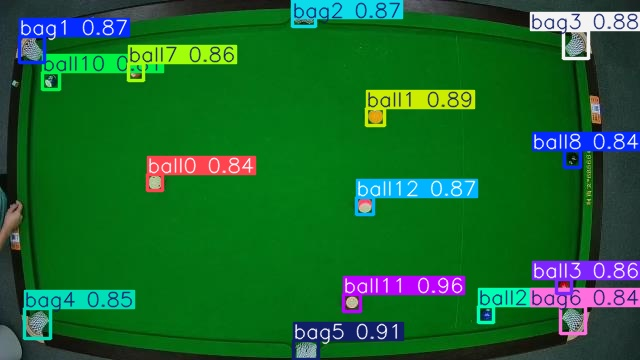

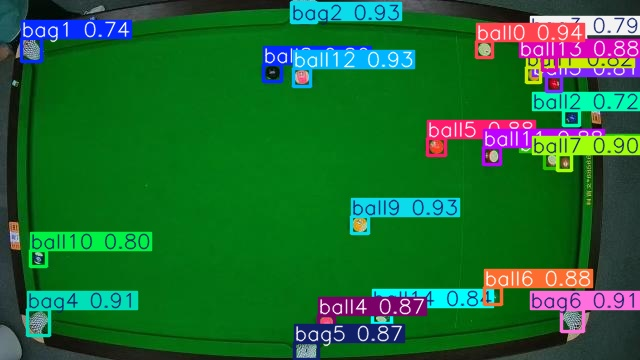

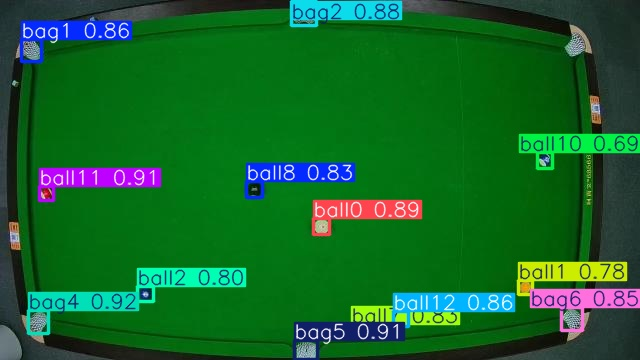

In [ ]:
import glob
import os
from IPython.display import Image as IPyImage, display

latest_folder = max(glob.glob(f'{HOME}/runs/detect/predict*/'), key=os.path.getmtime)
for img in glob.glob(f'{latest_folder}/*.jpg')[:3]:
    display(IPyImage(filename=img, width=600))
    print("\n")

## DOWNLOAD

In [ ]:
from google.colab import files
files.download(f'{HOME}/runs/detect/train/weights/best.pt')